# Mode Sources and Monitors

We launch one guided waveguide mode, verify the launched power in a straight reference waveguide, and then reuse the same source/monitor setup for a simple width-step junction. The important quantities are the frequency-domain fields, the total flux through a monitor plane, and the modal amplitudes returned by the mode monitor.

![header_image](./imgs/modal_header.png)

This notebook follows a very similar workflow as the [Tidy3D modal-source/modal-monitor example](https://www.flexcompute.com/tidy3d/examples/notebooks/ModalSourcesMonitors/) for direct comparison, while using BEAMZ's `Design` and `Material` API.

**Author:** Quentin Wach
**Published:** 2026-05-24
**Updated:** 2026-05-26
**Tags:** Simulation

![preview](attachment:imgs/modal.png)

## Setup
Let's first import the three libraries we need:

In [1]:
import beamz as bz
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120})

## Geometry, Band, and Grid

The design is a silicon strip waveguide on a silica substrate with air above it. Coordinates are centered on the simulation domain, so the source and monitor planes can be placed with simple signed offsets along `x`.

The frequency samples span a broad band around the source center frequency. `plane_size = (0, 3 um, 2 um)` means the source and mode-monitor planes are normal to `x`; the zero-sized dimension defines the propagation axis. The mode source itself is solved on this finite transverse window, not on the full simulation cross section.


In [2]:
# Define the unit length as micrometer
um = bz.um

# Height and width of the waveguide
wg_height = 0.22 * um
wg_width = 0.45 * um

# Permittivity of waveguide and substrate
si_eps = 3.48**2
sio2_eps = 1.45**2

# Free-space wavelength and frequency (in Hz)
lambda0 = 1.55 * um
freq0 = bz.LIGHT_SPEED / lambda0
fwidth = freq0 / 10

# Number of frequencies to solve for
nfreqs = 17
freqs = np.linspace(freq0 - 2 * fwidth, freq0 + 2 * fwidth, nfreqs)
lambdas_um = bz.LIGHT_SPEED / freqs / um
fcent_ind = nfreqs // 2

# Simulation size and PML thickness
sim_size = (8.0 * um, 7.0 * um, 6.0 * um)
pml_t = 1.25 * um
src_x = -sim_size[0] / 2 + pml_t + 0.75 * um
out_x = -src_x
plane_size = (0.0, 3.0 * um, 2.0 * um)
run_time = 20 / fwidth
boundary_spec = bz.BoundarySpec.all_sides(bz.PML(thickness=pml_t, formulation="cpml"))

# Mode source specification
source_time = bz.GaussianPulse(freq0=freq0, fwidth=fwidth)
mode_spec = bz.ModeSpec(num_modes=3, target_neff=0.98 * np.sqrt(si_eps))
source_polarization = "te"

# Grid specification
grid_spec = bz.GridSpec.auto(min_steps_per_wvl=8, wavelength=lambda0)

## Structures and Monitors

The straight reference simulation contains the substrate, the waveguide, and three monitors:

- `FieldMonitor` records the source-normalized frequency-domain field snapshot `Ey(x, y)` at the central frequency.
- `FluxMonitor` computes the area-integrated Poynting flux through the output plane.
- `ModeMonitor` decomposes the same output-plane fields into forward and backward waveguide modes.

For a harmonic field, the signed power crossing a plane is

$$
P = \frac{1}{2}\operatorname{Re}\int_A (\mathbf{E} \times \mathbf{H}^*) \cdot d\mathbf{A}.
$$

BEAMZ reports this in watts after source-spectrum normalization, matching the convention used by the modal amplitudes.


In [3]:
# Materials
mat_air = bz.Material(permittivity=1.0)
mat_wg = bz.Material(permittivity=si_eps)
mat_sub = bz.Material(permittivity=sio2_eps)

# Initialize air background
design = bz.Design(background=mat_air)

# Add the silica substrate
design += bz.Box(
    center=(0, 0, -0.5 * sim_size[2]),
    size=(bz.inf, bz.inf, sim_size[2]),
    material=mat_sub,
)

# Add the silicon waveguide
design += bz.Box(
    center=(0, 0, 0.5 * wg_height),
    size=(bz.inf, wg_width, wg_height),
    material=mat_wg,
)

# Source plane
src_plane = bz.Box(center=(src_x, 0, 0.0), size=plane_size)
field_mnt = bz.FieldMonitor(
    center=(0, 0, 0.5 * wg_height),
    size=(sim_size[0], sim_size[1], 0.0),
    freqs=[freq0],
    components=("Ey",),
    name="field",
)
flux_mnt = bz.FluxMonitor(center=(out_x, 0, 0.0), size=plane_size, freqs=freqs, name="flux")
mode_mnt = bz.ModeMonitor(
    center=(out_x, 0, 0.0),
    size=plane_size,
    freqs=freqs,
    mode_spec=mode_spec,
    name="mode",
    direction="+x",
    polarization="te",
    record_fields=False,
)

## Build and Inspect the Straight Simulation

This first simulation has no source. It provides the geometry, grid, and monitor planes used by the mode solver. Plotting the cross sections is a quick check that the substrate, waveguide, source plane, and output monitor are where we expect them to be before running FDTD.


● Info: Auto-selecting 3D meshing for 3D design
● Rasterizing 3D structures...
● Rasterizing 3D structures... done (3/3)
● Info: 3D raster timing: setup=0.02s, structures=0.03s, pml=0.00s, total=0.07s
● Info: 3D raster kernels: fast_enabled=True, fast_rect=2, fast_poly=0, fallback=0
● Done: Created 3D mesh: 143 × 125 × 107 cells
● Info: Raster cache saved: 24393a553437887c3fbf6bbadda0453571de9c4f7e287af673a36a31f2855b38.npz | save=0.47s
● Info: Rasterize wall-time: 0.07s | total=0.54s
dx = 0.056 um, steps = 9742


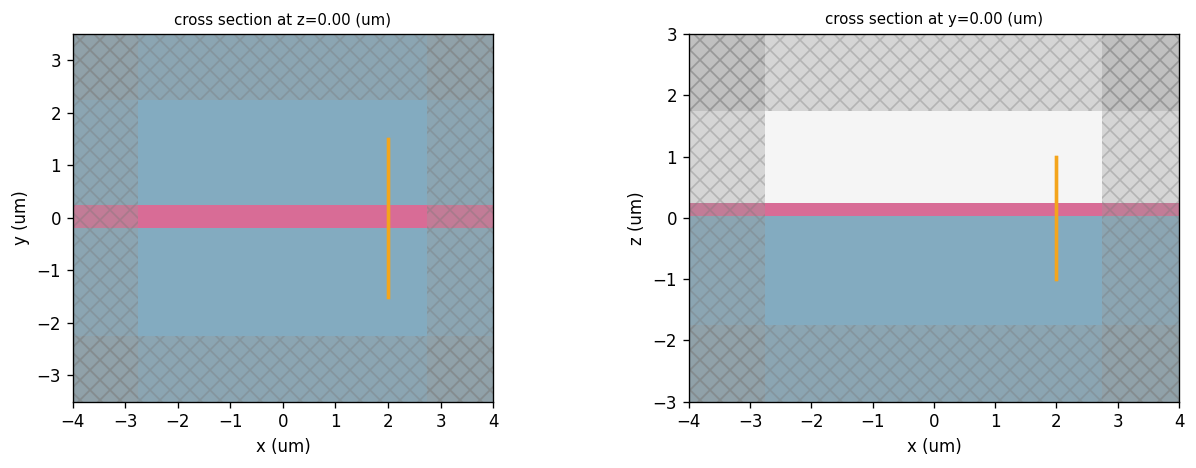

In [4]:
sim0 = bz.Simulation(
    domain=sim_size,
    grid_spec=grid_spec,
    design=design,
    sources=[],
    monitors=[field_mnt, flux_mnt, mode_mnt],
    boundary_spec=boundary_spec,
    run_time=run_time,
)
print(f"dx = {sim0.resolution / um:.3f} um, steps = {sim0.num_steps}")
fig, axes = sim0.plot(z=0.0, y=0.0, show=False)
plt.show()

## Solve Modes and Create the Mode Source

The mode solver finds fields of the form

$$
\mathbf{E}_p(y,z) e^{i\beta_p x}, \qquad \mathbf{H}_p(y,z) e^{i\beta_p x}, \qquad n_{\mathrm{eff},p}=\beta_p/k_0.
$$

The table lists the effective index and polarization fraction for the requested modes, and the field plots show the transverse mode profiles on the same finite plane used by the source.

We convert the selected mode into a directional equivalent-current source. The selected mode is power-normalized so that, at the center frequency, the target launch power is

$$
P_0 = \frac{1}{2}\operatorname{Re}\int_A (\mathbf{E}_0 \times \mathbf{H}_0^*) \cdot d\mathbf{A} = 1\ \mathrm{W}.
$$

Here we inject the fundamental TE-like mode in the `+x` direction.


wavelength     n eff         k eff  loss (dB/cm)  \
f            mode_index                                                     
1.934145e+14 0                 1.55  2.292638  0.000000e+00  0.000000e+00   
             1                 1.55  1.555285  3.963092e-17  1.395393e-11   
             2                 1.55  1.362922  0.000000e+00  0.000000e+00   

                         TE (Ey) fraction  wg TE fraction  wg TM fraction  \
f            mode_index                                                     
1.934145e+14 0                   0.965675        0.555119        0.005951   
             1                   0.068589        0.044074        0.071216   
             2                   0.011589        0.022764        0.009914   

                         mode area  
f            mode_index             
1.934145e+14 0            0.143408  
             1            0.437427  
             2            1.635246

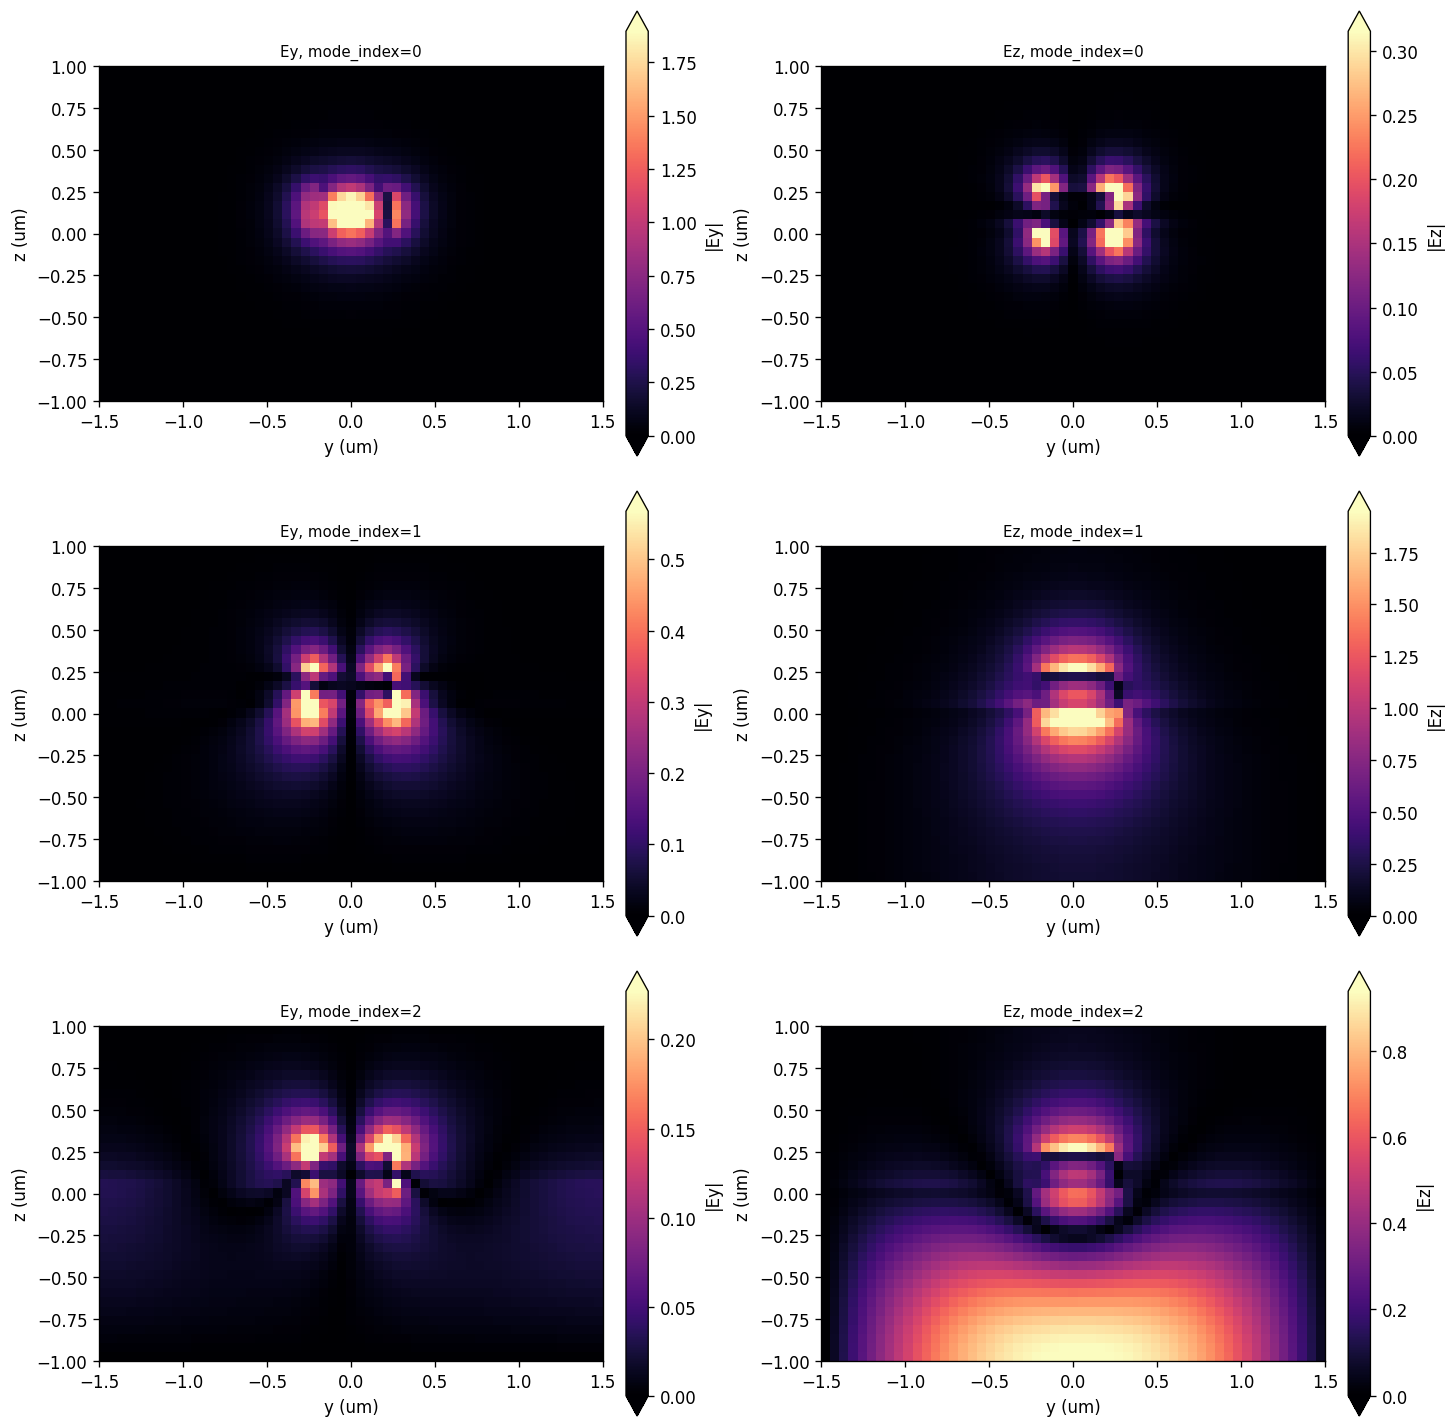

In [5]:
ms = bz.ModeSolver(simulation=sim0, plane=src_plane, mode_spec=mode_spec, freqs=[freq0])
modes = ms.solve()
fig, axes, neffs = ms.plot_field_components(
    field_names=("Ey", "Ez"),
    mode_indices=(0, 1, 2),
    val="abs",
    f=freq0,
    figsize=(12, 12),
    show=False,
)
display(modes.to_dataframe())
plt.show()

mode_source = ms.to_source(
    mode_index=0,
    direction="+",
    source_time=source_time,
    polarization=source_polarization,
    power=1.0,
)
sim = sim0.copy(update={"sources": [mode_source]})

## Run the Straight Waveguide

Now we add the mode source and run FDTD. The in-plane field plot is a frequency-domain DFT snapshot at `freq0`; BEAMZ source-normalizes this plot and displays electric fields in `V/um`.

The straight waveguide acts as a reference run: ideally nearly all power should remain in the forward fundamental mode, with very little backward power.


● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (9742/9742 steps)
completed 9742 FDTD steps


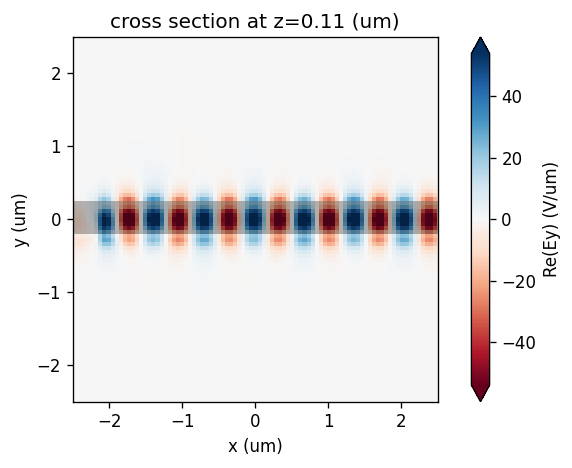

In [6]:
sim_data = sim.run(progress=True)
print(f"completed {sim.current_step} FDTD steps")
sim_data.plot_field("field", "Ey", frequency=freq0, val="real", cmap="RdBu", xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
plt.show()

## In-Plane Field and Mode Decomposition

The mode monitor expands the recorded fields in a power-normalized modal basis. With this normalization, `abs(a_p)^2` is the power in mode `p`, in watts. The total flux and the `mode_index=0` power should closely agree in the straight waveguide because the source is intended to launch only the fundamental guided mode.


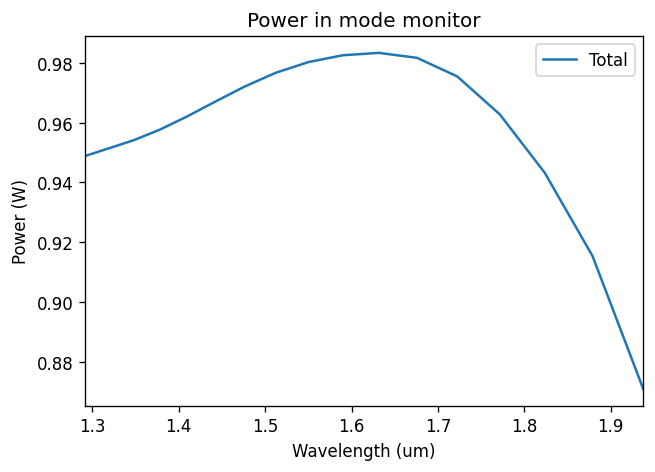

In [7]:
flux_wg = sim_data["flux"].flux
mode_amps = sim_data["mode"]
coeffs_f = mode_amps.amps.sel(direction="+")
coeffs_b = mode_amps.amps.sel(direction="-")

fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(lambdas_um, flux_wg)
ax.set_xlim([lambdas_um[-1], lambdas_um[0]])
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Power (W)")
ax.set_title("Power in mode monitor")
ax.legend(["Total", "Mode 0"])
plt.show()

## Width-Step Junction

The junction variant keeps the same source and monitor definitions, but replaces the output half of the waveguide with a wider guide. This creates a simple discontinuity where the input mode can scatter into radiation and into several modes of the wider section.


● Info: Auto-selecting 3D meshing for 3D design
● Rasterizing 3D structures...
● Rasterizing 3D structures... done (4/4)
● Info: 3D raster timing: setup=0.03s, structures=0.03s, pml=0.00s, total=0.08s
● Info: 3D raster kernels: fast_enabled=True, fast_rect=3, fast_poly=0, fallback=0
● Done: Created 3D mesh: 143 × 125 × 107 cells
● Info: Raster cache saved: 1eaf0b1f7c4a74d49c2689d261b6b4d1189027fdc50daa4417c67fba149578ca.npz | save=0.86s
● Info: Rasterize wall-time: 0.08s | total=0.94s


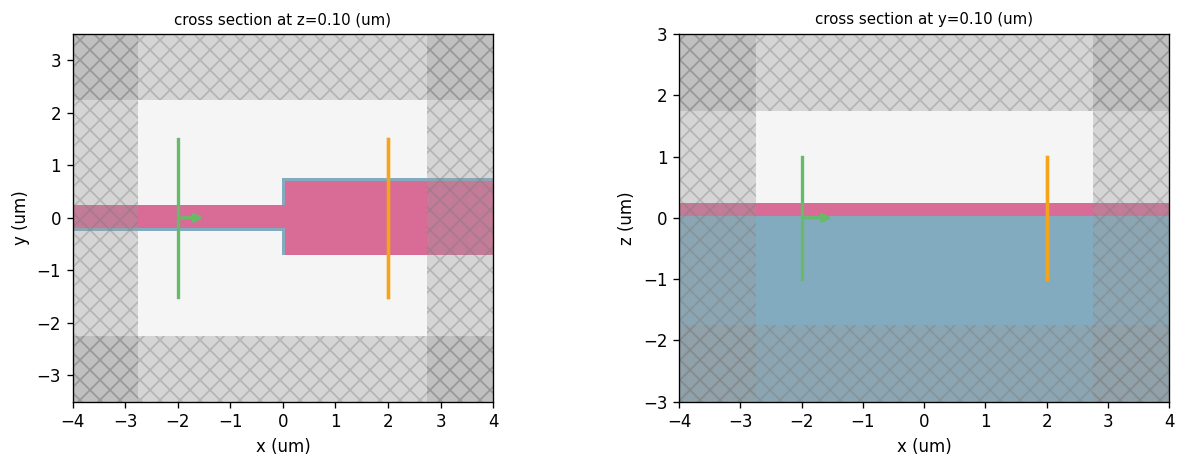

In [8]:
wgout_width = 1.4 * um
design_jct = design.copy()
design_jct += bz.Box(
    center=(0.25 * sim_size[0], 0, 0.5 * wg_height),
    size=(0.5 * sim_size[0], wgout_width, wg_height),
    material=mat_wg,
)

sim_jct0 = bz.Simulation(
    domain=sim_size,
    grid_spec=grid_spec,
    design=design_jct,
    sources=[],
    monitors=[field_mnt, flux_mnt, mode_mnt],
    boundary_spec=boundary_spec,
    run_time=run_time,
)
sim_jct = sim_jct0.copy(update={"sources": [mode_source]})
fig, axes = sim_jct.plot(z=0.1 * um, y=0.1 * um, width_ratios=[1, 1.4], show=False)
plt.show()

In [9]:
sim_data_jct = sim_jct.run(progress=True)
print(f"completed {sim_jct.current_step} FDTD steps")

● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (9742/9742 steps)
completed 9742 FDTD steps


## Junction Fields and Normalized Mode Powers

The field snapshot shows the interference and spreading after the width step. For the modal plot, the junction amplitudes are normalized by the straight-waveguide reference flux. This removes the residual frequency dependence of the source launch and makes the plotted curves easier to interpret as junction power fractions.

If the computed modal powers do not sum to one, the missing part is power scattered into radiation, reflected modes, modes outside the requested basis, or numerical loss.


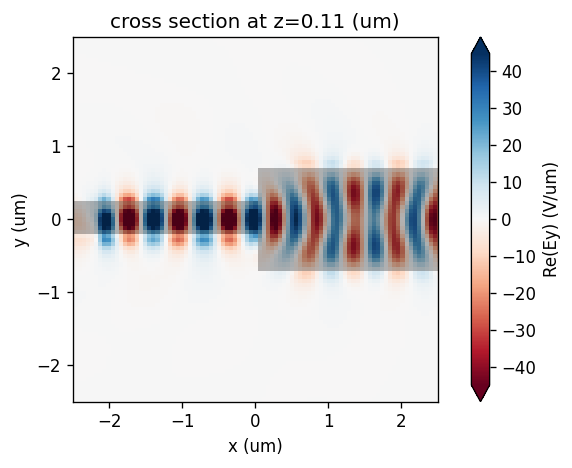

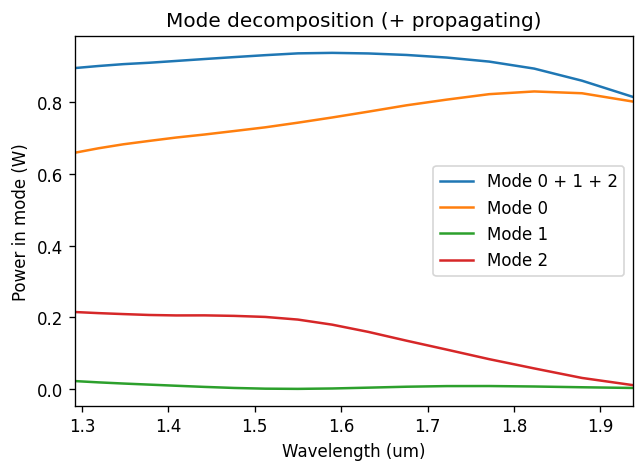

In [10]:
sim_data_jct.plot_field("field", "Ey", frequency=freq0, val="real", cmap="RdBu", xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
plt.show()

amps_jct = sim_data_jct["mode"].amps.sel(direction="+")
amps_jct = amps_jct / np.sqrt(np.maximum(flux_wg.values, 1e-18))[:, None]

fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(lambdas_um, np.sum(np.abs(amps_jct.values) ** 2, axis=1))
ax.plot(lambdas_um, np.abs(amps_jct.values) ** 2)
ax.set_xlim([lambdas_um[-1], lambdas_um[0]])
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Power in mode (W)")
ax.set_title("Mode decomposition (+ propagating)")
ax.legend(["Mode 0 + 1 + 2", "Mode 0", "Mode 1", "Mode 2"])
plt.show()